In [6]:
""" Compare against Colleen's resin exchange data"""
import pandas as pd
import numpy as np
import os
from datetime import datetime
from utils.constants import chamber_levels_complete, chamber_list_complete_dict
import matplotlib.pyplot as plt
from glob import glob
import xarray as xr
from scipy.stats import spearmanr

chambers_ordered = {
    'amb': ['06', '20', '13', '08', '17'], 
    'elev': ['19', '11', '04', '16', '10']
}
depth_list = ['0.1', '0.3', '0.6']

mossfrac = pd.read_excel(
    os.path.join(os.environ['HOME'], 'Git', 'phenology_elm', "Sphagnum_fraction.xlsx"),
    index_col=0, skiprows=1, engine="openpyxl"
).drop(["plot", "Temp", "CO2"], axis=1)
mossfrac[2015] = mossfrac[2016]
mossfrac.sort_index(axis = 1, inplace = True)

In [7]:
data = pd.read_csv(
    os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'input', 
                 'SPRUCE_Available_Nutrients_Ion-Exchange-Resins_Annual_2014-2018.csv'),
    na_values = -9999
)
data = data.loc[data['Year'] >= 2015, :]
data['Peat_depth'] = data['Peat_depth'].map({10: 0.1, 30: 0.3, 60: 0.6})
data['Plot'] = [f'{p:02d}' for p in data['Plot']]

In [8]:
# Collect modeled dissolved nutrients, layersize
#prefix = '20231113'
prefix = '20240321'
ensemble_id = None
year_range = range(2015, 2022)
plot_list = list(chamber_levels_complete.keys())

sims_data = {}
sims_data['SMINN_TO_NPOOL'] = \
    pd.DataFrame(np.nan, 
                 columns = pd.MultiIndex.from_product([['hummock', 'hollow'],
                                                        plot_list]),
                 index = range(2015, 2022))
sims_data['SMINP_TO_PPOOL'] = sims_data['SMINN_TO_NPOOL'].copy()
sims_data['NET_NMIN'] = sims_data['SMINN_TO_NPOOL'].copy()
sims_data['NET_PMIN'] = sims_data['SMINN_TO_NPOOL'].copy()
sims_data['TBOT'] = sims_data['SMINN_TO_NPOOL'].copy()

for plot in plot_list:
    if not "UQ" in prefix:
        rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                              f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                              f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run')
    else:
        rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                              f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ensemble_id, 
                              f'P{chamber_list_complete_dict[plot]}')

    flist = sorted(glob(rundir + "/*.h2.*.nc"))
    flist = [f for f in flist if \
             int(f.split('/')[-1].split('.')[-2].split('-')[0]) in year_range]
    hr = xr.open_mfdataset(flist)
    for var in ['SMINN_TO_NPOOL', 'SMINP_TO_PPOOL']:
        for hol_add, colname in zip([0, 17], ['hummock', 'hollow']):
            temp = hr[var][ (hr['time'].to_index().month >= 5) & \
                            (hr['time'].to_index().month <= 9), : ]
            temp = temp.resample(time = '1Y').mean()
            temp = pd.DataFrame(temp.values, index = temp['time'].to_index().year, 
                                columns = range(64))
            spruce = temp.loc[:, hol_add + 3].values * 0.36
            tamarack = temp.loc[:, hol_add + 3].values * 0.14
            shrub = temp.loc[:, hol_add + 11].values * 0.25
            moss = temp.loc[:, hol_add + 12].values * mossfrac.loc[
                chamber_list_complete_dict[f'P{plot}'], :
            ].values.reshape(1, -1)

            sims_data[var].loc[:, (colname, plot)] = spruce + tamarack + shrub + moss
    hr.close()

    flist = sorted(glob(rundir + "/*.h1.*.nc"))
    flist = [f for f in flist if \
             int(f.split('/')[-1].split('.')[-2].split('-')[0]) in year_range]
    hr = xr.open_mfdataset(flist)
    for var in ['TBOT', 'NET_NMIN', 'NET_PMIN']:
        for col, colname in zip([0, 1], ['hummock', 'hollow']):
            temp = hr[var][ (hr['time'].to_index().month >= 5) & \
                            (hr['time'].to_index().month <= 9), col]
            temp = temp.resample(time = '1Y').mean()
            if var == 'TBOT':
                temp = temp - 273.15
            sims_data[var].loc[:, (colname, plot)] = temp

    hr.close()

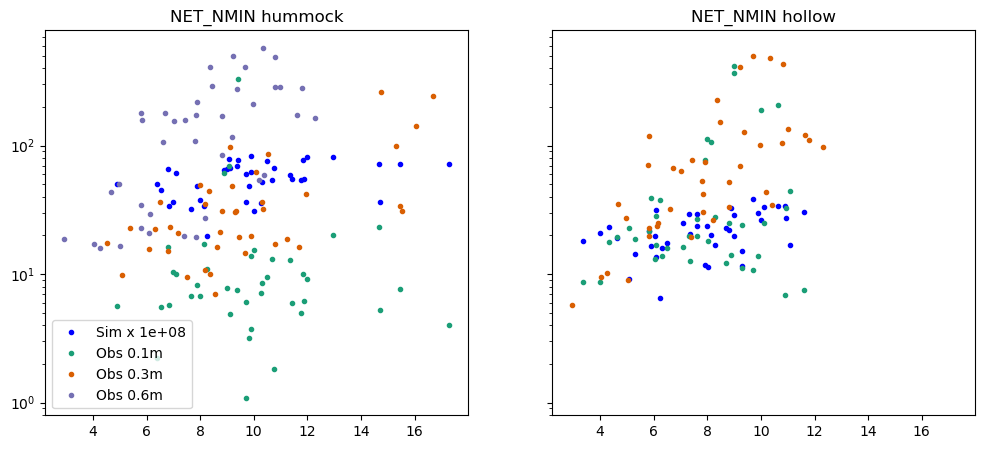

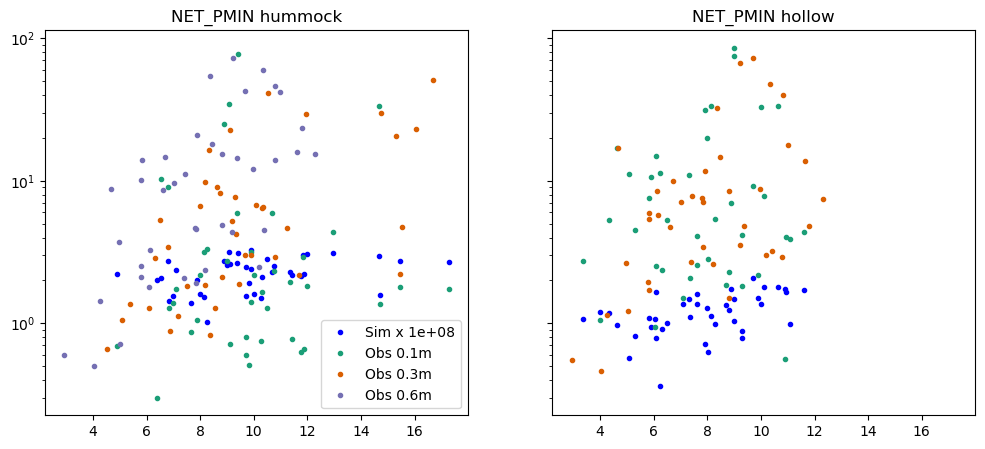

In [9]:
xticklabels = ['0 amb', '2.25 amb','4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

clist = ['#1b9e77', '#d95f02', '#7570b3']

for nu, sim_name, obs_name in zip(
    ['N', 'P'], ['NET_NMIN', 'NET_PMIN'], ['Ammonium', 'Phosphate']
):
    # hummock, hollow
    fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)

    for i, hol in enumerate(['hummock', 'hollow']):
        ax = axes.flat[i]

        for d, depth in enumerate([0.1, 0.3, 0.6]):
            # observed temperature & data
            obs_temp = data.loc[(data['Microtopography'] == hol.capitalize()) &
                                np.isclose(data['Peat_depth'], depth), 
                ['Plot', 'Year', 'Annual_Peat_temperature', 
                obs_name]].groupby(['Plot','Year']).mean()

            # growing season simulated data
            sims_data_var = sims_data[sim_name].loc[:, hol].unstack()
            sims_data_var.index.names = ['Plot', 'Year']
            sims_data_var = sims_data_var.to_frame(sim_name)

            # put together
            alldata = pd.concat([obs_temp, sims_data_var], axis = 1).dropna(axis = 0, how = 'any')

            if d == 0:
                # model - no depth info available
                if 'POOL' in sim_name:
                    factor = 5e6
                else:
                    factor = 1e8
                ax.plot(alldata['Annual_Peat_temperature'], alldata[sim_name] * factor, 'o', 
                        label = f'Sim x {factor:g}', color = 'b', # markerfacecolor = 'none', 
                        markersize = 3)

            # data at different depth
            ax.plot(alldata['Annual_Peat_temperature'], alldata[obs_name], 'o', 
                    label = f'Obs {depth}m', color = clist[d], # markerfacecolor = 'none', 
                    markersize = 3)

        ax.set_title(f'{sim_name} {hol}')
        if i == 0:
            ax.legend()
        ax.set_yscale('log')

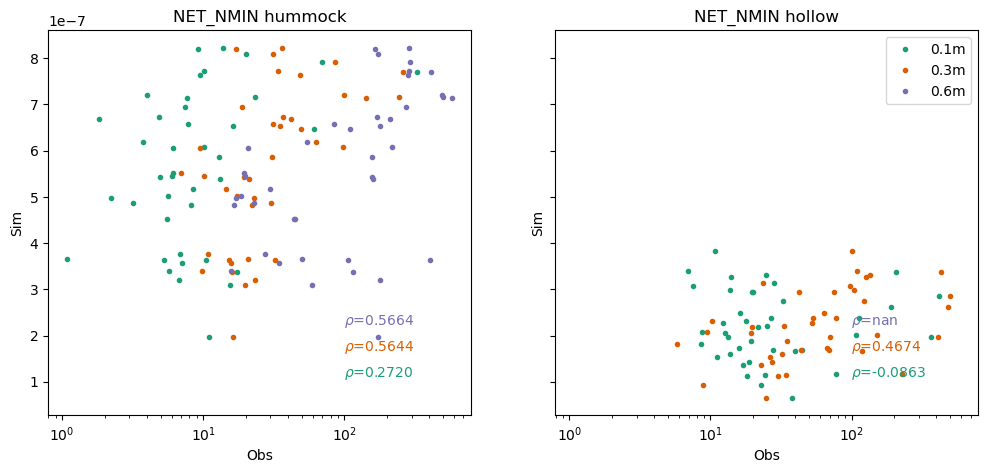

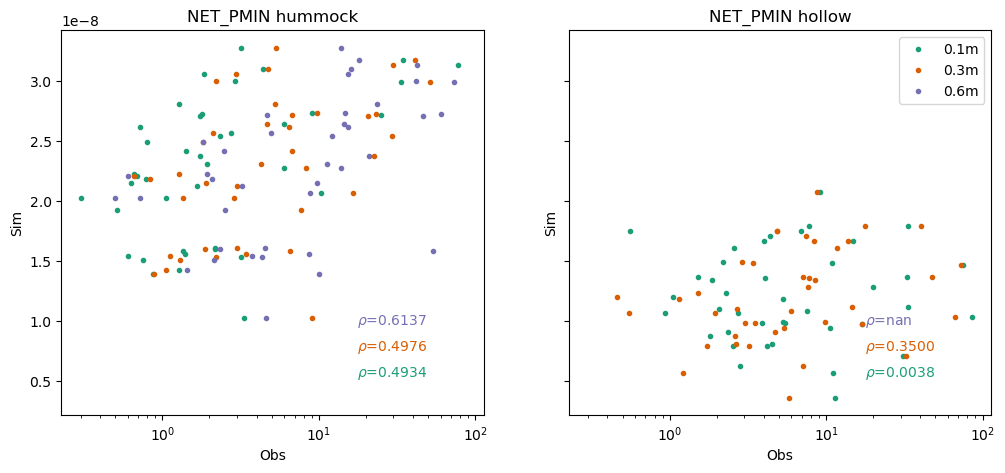

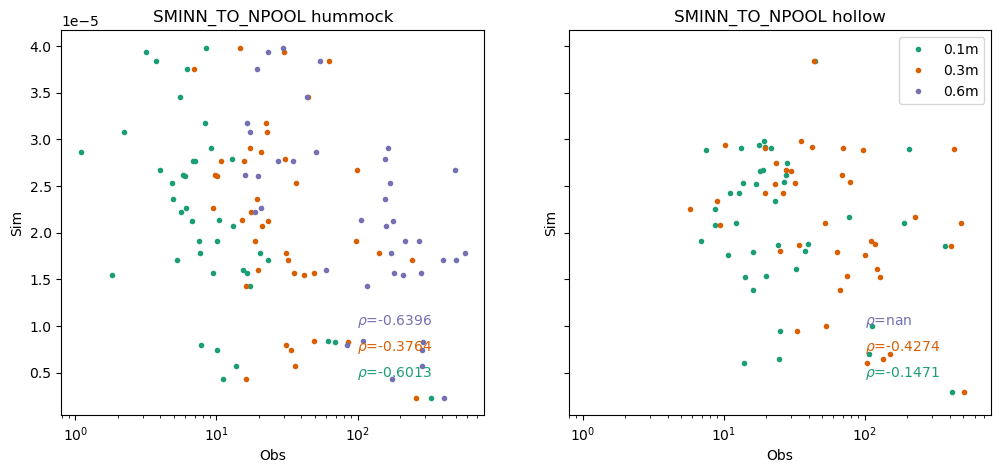

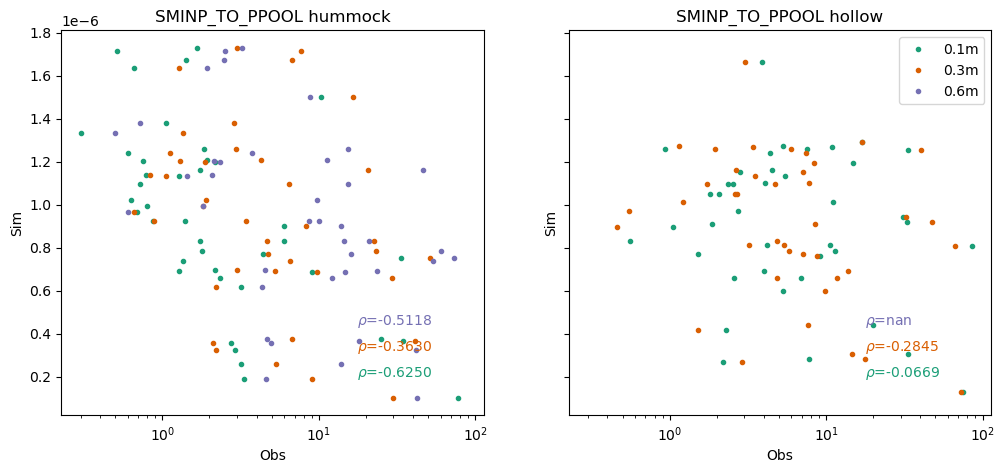

In [11]:
xticklabels = ['0 amb', '2.25 amb', '4.5 amb', '6.75 amb', '9 amb', 
               '0 elev', '2.25 elev', '4.5 elev', '6.75 elev', '9 elev']

clist = ['#1b9e77', '#d95f02', '#7570b3']

for nu, sim_name, obs_name in zip(
    ['N', 'P', 'N', 'P'], ['NET_NMIN', 'NET_PMIN','SMINN_TO_NPOOL','SMINP_TO_PPOOL'], 
    ['Ammonium', 'Phosphate', 'Ammonium', 'Phosphate']
):
    # hummock, hollow
    fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)

    for i, hol in enumerate(['hummock', 'hollow']):
        ax = axes.flat[i]

        for d, depth in enumerate([0.1, 0.3, 0.6]):
            # observed temperature & data
            obs_temp = data.loc[(data['Microtopography'] == hol.capitalize()) &
                                np.isclose(data['Peat_depth'], depth), 
                ['Plot', 'Year', 'Annual_Peat_temperature', 
                obs_name]].groupby(['Plot','Year']).mean()

            # growing season simulated data
            sims_data_var = sims_data[sim_name].loc[:, hol].unstack()
            sims_data_var.index.names = ['Plot', 'Year']
            sims_data_var = sims_data_var.to_frame(sim_name)

            # put together
            alldata = pd.concat([obs_temp, sims_data_var], axis = 1).dropna(axis = 0, how = 'any')

            #
            ax.plot(alldata[obs_name], alldata[sim_name], 'o', color = clist[d], 
                    label = f'{depth}m', markersize = 3)

            rho,pval = spearmanr(alldata[obs_name], alldata[sim_name])
            ax.text(0.7, 0.1+d/15, r'$\rho$=' + f'{rho:.4f}', transform = ax.transAxes, 
                    color = clist[d])
            if i == 1:
                ax.legend()

        ax.set_xlabel('Obs')
        ax.set_ylabel('Sim')
        ax.set_xscale('log')

        ax.set_title(f'{sim_name} {hol}')

In [ ]:
# make resin time series data

# resin v.s. root production